In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [4]:
data = pd.read_csv("StudentPerformanceFactors.csv")

In [5]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Исходя из базового среза данных, существует несколько типов объектов: int (цифры), object (категории). При этом, уже на данном этапе усматривается, что в данных есть пропуски в колонках Teacher_Quality, Parental_Education_level, Distance_from_Home. Суммарно до обработки в датасете 6607 строк, 20 колонок.

## Описание переменных
- Hours_Studied: Количество часов, затраченных на учебу в неделю.
- Attendance: Процент посещаемости занятий.
- Parental_Involvement: Уровень вовлеченности родителей (низкий, средний, высокий).
- Access_to_Resources: Доступ к образовательным ресурсам (низкий, средний, высокий).
- Extracurricular_Activities: Участие во внеклассных мероприятиях (да/нет).
- Sleep_Hours: Среднее количество часов сна в сутки.
- Previous_Scores: Баллы, полученные на предыдущих экзаменах.
- Motivation_Level: Уровень мотивации студента (низкий, средний, высокий).
- Internet_Access: Наличие доступа к интернету дома (да/нет).
- Tutoring_Sessions: Количество дополнительных занятий с репетитором в неделю.
- Family_Income: Уровень дохода семьи (низкий, средний, высокий).
- Teacher_Quality: Оценка качества преподавания (низкое, среднее, высокое).
- School_Type: Тип школы (государственная / частная).
- Peer_Influence: Влияние сверстников (положительное, нейтральное, отрицательное).
- Physical_Activity: Количество часов физической активности в неделю.
- Learning_Disabilities: Наличие диагностированных нарушений обучаемости (да/нет).
- Parental_Education_Level: Наивысший уровень образования родителей (школа, колледж, послевузовское).
- Distance_from_Home: Расстояние от дома до школы (близко, умеренно, далеко).
- Gender: Пол студента (мужской/женский).
- Exam_Score: Итоговый балл на экзамене (целевая переменная).

In [7]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


По анализу числовых переменных сразу бросается в глаза то, что результат экзамена явно не может быть более, чем 100, а в таблице выше видно, что показатель больше. 
На этапах ранее фиксировалось, что есть пропуски в категориальных переменных, которые обработать в целом сложнее. В данном же случае проблема с числовой переменной, что упрощает работу по очистке данных. 

In [10]:
data[data["Exam_Score"]>100] #получается, что выброс по сути один
# видится нерелевантным его корректировать до 100 тк нет уверенности в том, что там такое значение, а ошибка 100% есть => delite

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [11]:
data_v1 = data[data["Exam_Score"]<=100]

In [20]:
# остальные проблемные данные предлагается также убрать просто тк заполнять может быть некорретно + их не так много:
# удалим строки, где есть пропуски в любой из этих трех колонок
data_v2 = data_v1.dropna(subset=['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']).copy()

In [21]:
data_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6377 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6377 non-null   int64 
 1   Attendance                  6377 non-null   int64 
 2   Parental_Involvement        6377 non-null   object
 3   Access_to_Resources         6377 non-null   object
 4   Extracurricular_Activities  6377 non-null   object
 5   Sleep_Hours                 6377 non-null   int64 
 6   Previous_Scores             6377 non-null   int64 
 7   Motivation_Level            6377 non-null   object
 8   Internet_Access             6377 non-null   object
 9   Tutoring_Sessions           6377 non-null   int64 
 10  Family_Income               6377 non-null   object
 11  Teacher_Quality             6377 non-null   object
 12  School_Type                 6377 non-null   object
 13  Peer_Influence              6377 non-null   object
 1

По итогам очистки пропусков осталось 6377 переменных, но необходимо еще визуально оценить полученный результат

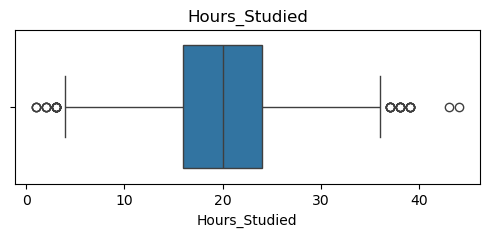

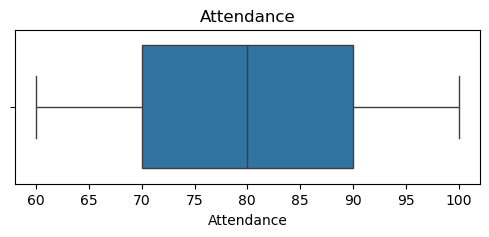

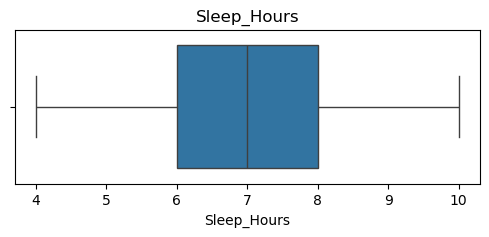

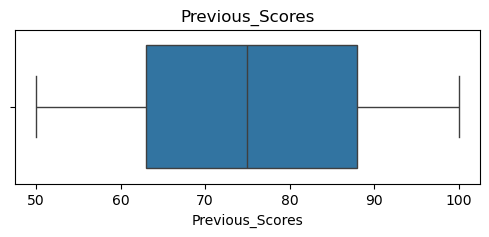

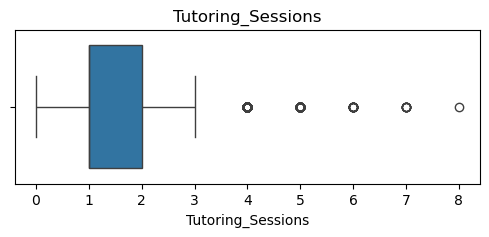

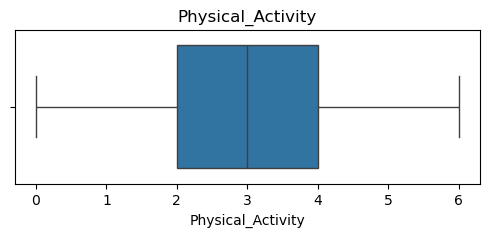

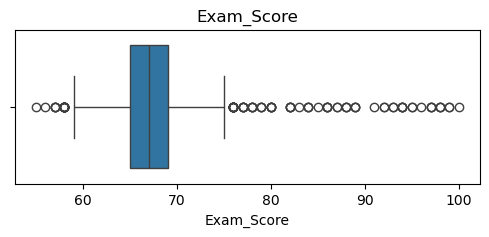

In [22]:
import matplotlib.pyplot as plt

numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=data_v2[col])
    plt.title(col)
    plt.show()

In [23]:
# преобразование категориальных переменных в числовой формат:
# порядковые
order_maps = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2}
}
for col, mapping in order_maps.items():
    data_v2[col] = data_v2[col].map(mapping)

# оne-hot для номинальных
nominal_cols = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities', 'School_Type', 'Gender']
data_v3 = pd.get_dummies(data_v2, columns=nominal_cols, drop_first=True)  # drop_first чтобы избежать мультиколлинеарности

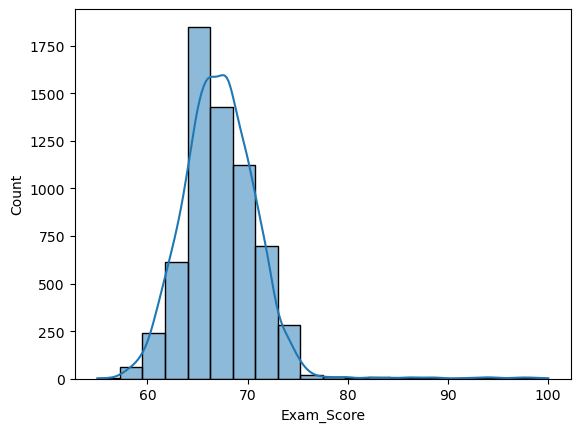

In [24]:
# визуализация целевой переменной: Exam_Score
sns.histplot(data_v3['Exam_Score'], bins=20, kde=True)
plt.show()

Исходя из визуальной составляющей целевой переменной можно увидеть, что в целом значения похожи на нормальное распределение, так что в целом все ок на данном этапе

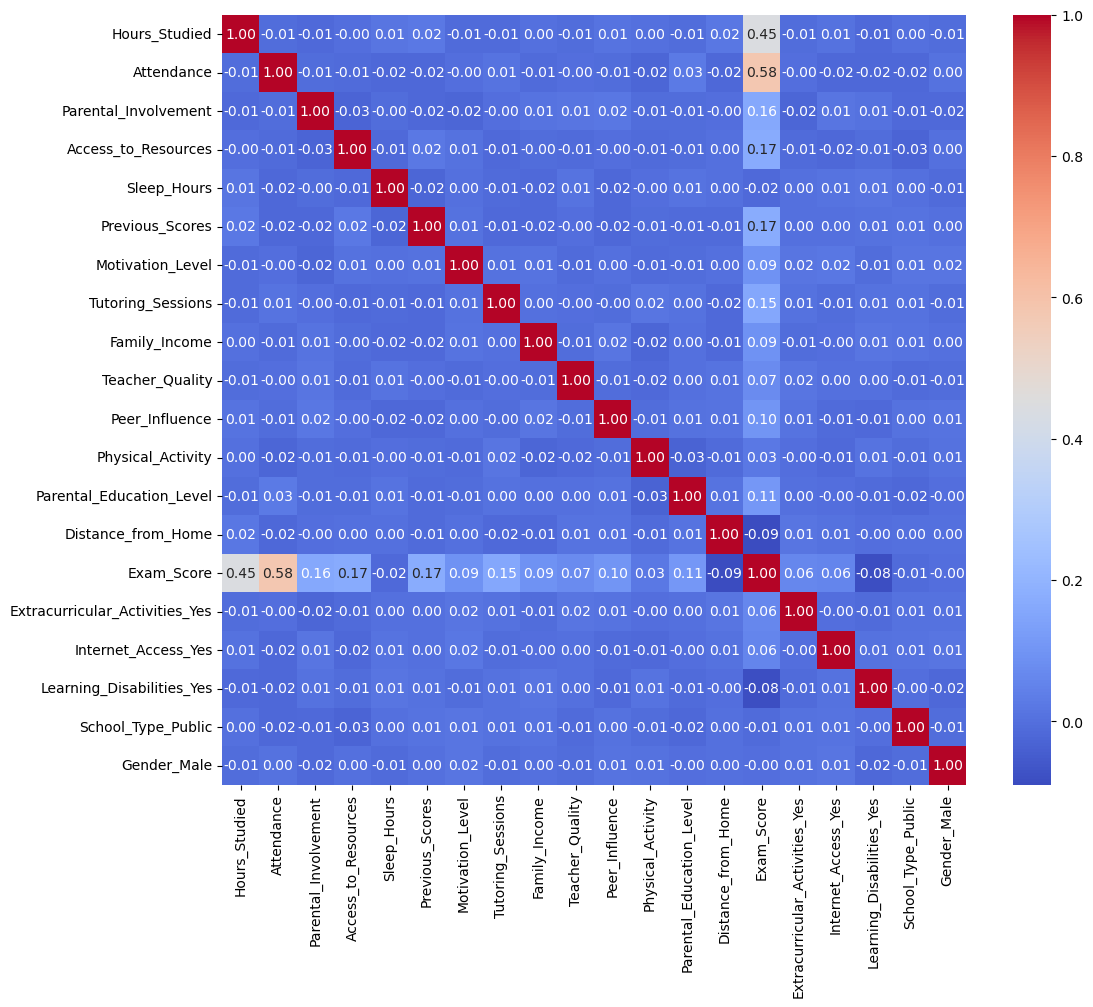

In [25]:
# тепловая карта корреляций в рамках "знакомства" с данными:
plt.figure(figsize=(12,10))
sns.heatmap(data_v3.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

Как можно заметить, наибольшая связь существует у целевой переменной в основном с учебными часами и посещаемостью. В остальном корреляции достаточно низкие, что в целом достаточно хорошо (и логично, в целом).

Логика дальнейшей работы складывается следующим образом: на первом этапе будет разработана модель, предсказывающая оценку за экзамен у студента при тех или иных параметрах, а на втором - будет смоделирован классификатор, который уже в дальнейшем ляжет в основу бизнес-задачи.

Относительно логики первого этапа предлагается реализовать несколько типов моделей, чтобы в конечном итоге выбрать наилучший

In [26]:
# подготовка данных к обучению

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# отделяем целевую переменную
X = data_v3.drop('Exam_Score', axis=1)
y = data_v3['Exam_Score']

# разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# для линейных моделей масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# регрессия

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"R²: {r2_score(y_test, y_pred_lr):.3f}")

Linear Regression:
RMSE: 2.036
MAE: 0.474
R²: 0.735


In [29]:
# ридж-регрессия

ridge = Ridge()
param_grid = {'alpha': np.logspace(-3, 3, 10)}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

print("\nRidge Regression (best alpha = {:.3f}):".format(ridge_cv.best_params_['alpha']))
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.3f}")
print(f"R²: {r2_score(y_test, y_pred_ridge):.3f}")


Ridge Regression (best alpha = 2.154):
RMSE: 2.036
MAE: 0.474
R²: 0.735


In [30]:
# случайный лес

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_cv = GridSearchCV(rf, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_cv.fit(X_train, y_train)  # масштабирование не нужно

best_rf = rf_cv.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest (best params: {}):".format(rf_cv.best_params_))
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"R²: {r2_score(y_test, y_pred_rf):.3f}")


Random Forest (best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}):
RMSE: 2.381
MAE: 1.107
R²: 0.638


In [33]:
!pip install xgboost #установка модуля для градиентного бустинга

In [34]:
# градиентный бустинг

import xgboost as xgb

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb_cv = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train, y_train)

best_xgb = xgb_cv.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("\nXGBoost (best params: {}):".format(xgb_cv.best_params_))
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"R²: {r2_score(y_test, y_pred_xgb):.3f}")


XGBoost (best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}):
RMSE: 2.155
MAE: 0.671
R²: 0.703


По результатам применения различных моделей усматривается, что регрессии дают более высокий коэффициент R2, что свидетельствует о том, что они "объясняют" происхождение целевой переменной лучше, чем случайный лес и градиентный бустинг. Плюс, MAE менее 0.5 балла при диапазоне оценок 55–100 также говорит об высокой точности прогнозов. 

Так как линейные модели показали наилучший результат - дальнейшие действия будем производить при помощи их

In [35]:
# рассмотрим величину коэффициентов при переменных:

coef = best_ridge.coef_  # для масштабированных признаков
feature_names = X.columns

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("Топ-10 признаков по абсолютному влиянию:")
print(coef_df.head(10))

Топ-10 признаков по абсолютному влиянию:
                     feature      coef  abs_coef
1                 Attendance  2.268668  2.268668
0              Hours_Studied  1.745174  1.745174
3        Access_to_Resources  0.717183  0.717183
2       Parental_Involvement  0.706627  0.706627
5            Previous_Scores  0.684249  0.684249
7          Tutoring_Sessions  0.583409  0.583409
8              Family_Income  0.399166  0.399166
12  Parental_Education_Level  0.396255  0.396255
6           Motivation_Level  0.390711  0.390711
10            Peer_Influence  0.370588  0.370588


На основаниии таблицы - факторы с наибольшим коэффициентом по модулю - имеют положительный знак при коэффициенте => увеличение влечет увеличение целевой переменной (оценки). Наибольший вес у посещаемости и учебных часов. Также значимое положительное влияние оказывают доступ к образовательным ресурсам, вовлеченность родителей, результаты предыдущих экзаменов и дополнительные занятия с репетитором. Чуть слабее, но всё же заметно сказываются уровень дохода семьи, образование родителей, мотивация студента и влияние сверстников

На основе полученной модели - построим новый признак "Группа риска". Он будет нужен для того, чтобы определять студентов, с большим потенциалом написать экзамен на низкий балл.

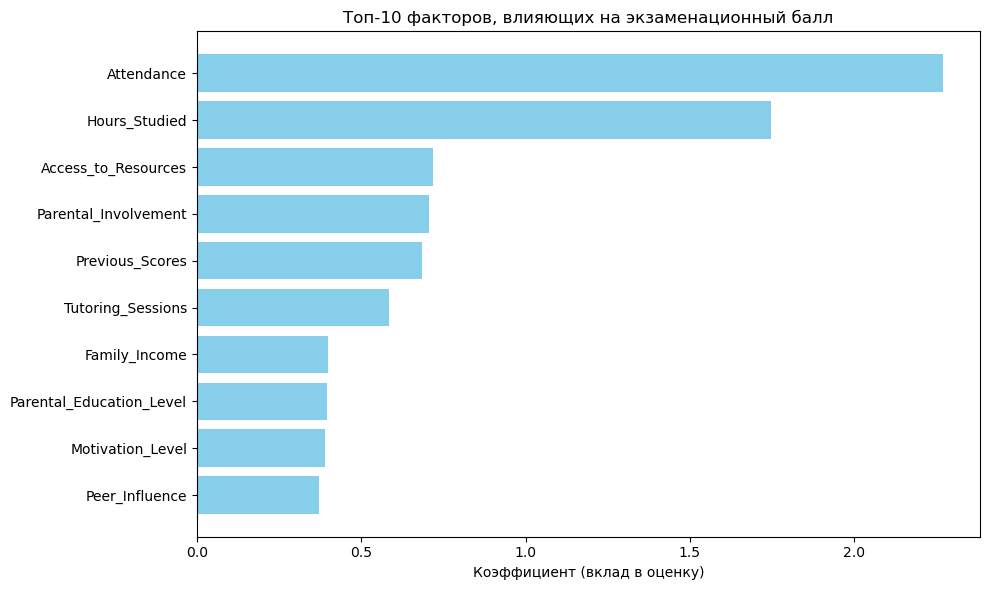

In [37]:
import matplotlib.pyplot as plt

top_features = coef_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['coef'], color='skyblue')
plt.xlabel('Коэффициент (вклад в оценку)')
plt.title('Топ-10 факторов, влияющих на экзаменационный балл')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
X_scaled = scaler.transform(X)
data_v3['Predicted_Score'] = best_ridge.predict(X_scaled)

# определяем группу риска (прогноз ниже 60)
threshold = 60
data_v3['Risk_Flag'] = (data_v3['Predicted_Score'] < threshold).astype(int)

# статистика по группе риска
risk_count = data_v3['Risk_Flag'].sum()
total_count = len(data_v3)
print(f"Доля студентов в группе риска: {risk_count / total_count:.2%} ({risk_count} из {total_count})")

# средние характеристики группы риска
risk_stats = data_v3[data_v3['Risk_Flag'] == 1].describe()
print("\nСредние показатели студентов группы риска:")
print(risk_stats[['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions']])

Доля студентов в группе риска: 1.19% (76 из 6377)

Средние показатели студентов группы риска:
       Hours_Studied  Attendance  Previous_Scores  Tutoring_Sessions
count      76.000000   76.000000        76.000000          76.000000
mean       10.328947   63.868421        69.276316           0.828947
std         4.455373    3.774801        13.224824           1.050564
min         2.000000   60.000000        50.000000           0.000000
25%         7.000000   61.000000        58.750000           0.000000
50%        11.000000   63.000000        67.500000           0.500000
75%        13.250000   66.000000        76.250000           1.000000
max        21.000000   79.000000        99.000000           4.000000


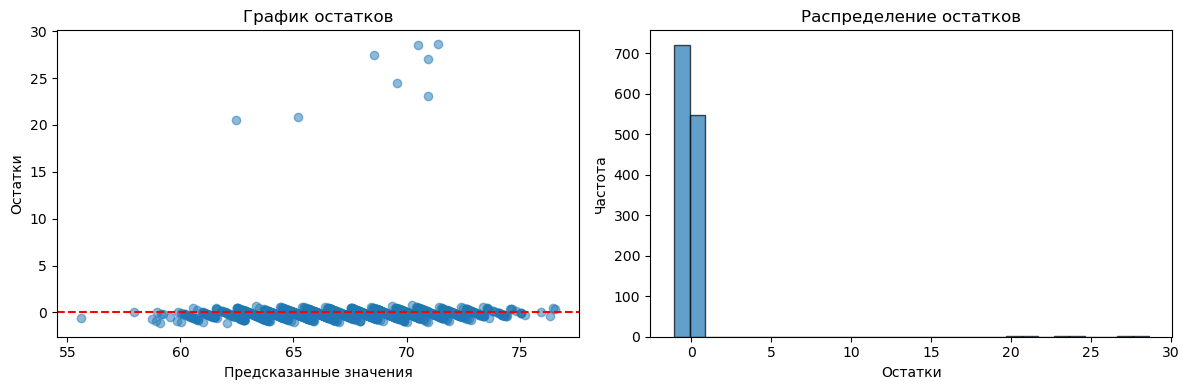

In [38]:
# проверка адекватности модели на оставшихся данных:

residuals = y_test - y_pred_ridge

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_ridge, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков')
plt.tight_layout()
plt.show()

На левом графике видно, что основная масса остатков сконцентрирована вокруг нулевой линии, что свидетельствует о хорошей предсказательной способности модели для большинства наблюдений. Однако присутствуют отдельные выбросы – студенты, для которых ошибка прогноза оказалась существенно выше средней, что может указывать на наличие уникальных характеристик, не учтенных моделью. Гистограмма справа демонстрирует распределение остатков, близкое к нормальному: симметричная форма и концентрация значений около нуля подтверждают корректность применения линейной регрессии и отсутствие систематических смещений. В целом диагностика показывает, что модель состоятельна, а ее редкие отклонения носят случайный характер и не влияют на общую надежность прогнозов.

In [39]:
data_v3.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,Learning_Disabilities_Yes,School_Type_Public,Gender_Male,Predicted_Score,Risk_Flag
0,23,84,0,2,7,73,0,0,0,1,...,0,0,67,False,True,False,True,True,67.001607,0
1,19,64,0,1,8,59,0,2,1,1,...,1,1,61,False,True,False,True,False,60.936354,0
2,24,98,1,1,7,91,1,2,1,1,...,2,0,74,True,True,False,True,True,74.234445,0
3,29,89,0,1,8,98,1,1,1,1,...,0,1,71,True,True,False,True,True,70.786228,0
4,19,92,1,1,6,65,1,3,1,2,...,1,0,70,True,True,False,True,False,70.848043,0


In [40]:
# сделаем импорт полученного файла для работы по составлению дашборда:
data_v3.to_excel('data_v3.xlsx', index=False)